# CISB5123 Text Analytics — Project Part 1
## Sentiment Analysis on Grab App Reviews (Google Play Store)
### Data Collection & Preprocessing
#### Osama Mohammed Ali Abdaslam 
#### SW01084153
---

## Import Libraries

In [56]:
# --- Standard Libraries ---
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

# --- Google Play Scraper ---
from google_play_scraper import reviews, Sort

# --- NLTK for NLP Preprocessing ---
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

print('All libraries loaded successfully!')

All libraries loaded successfully!


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\osaal\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\osaal\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\osaal\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\osaal\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


---
## Data Collection — Scraping Grab Reviews from Google Play Store

I use the `google-play-scraper` library to collect user reviews for the **Grab** app (`com.grabtaxi.passenger`).
I collect **1,000 reviews** sorted by the most recent entries, capturing both positive and negative feedback.

In [57]:
# Grab app package ID on Google Play Store
GRAB_APP_ID = 'com.grabtaxi.passenger'

# Scrape 1000 reviews (most recent)
print('Scraping Grab reviews from Google Play Store...')

result, continuation_token = reviews(
    GRAB_APP_ID,
    lang='en',          # English reviews only
    country='my',       # Malaysia region
    sort=Sort.NEWEST,   # Most recent first
    count=1000          # Total reviews to collect
)

print(f'Successfully scraped {len(result)} reviews!')

Scraping Grab reviews from Google Play Store...
Successfully scraped 1000 reviews!


In [58]:
# Convert to DataFrame and select relevant columns
df_raw = pd.DataFrame(result)

# Keep only relevant columns
df = df_raw[['userName', 'score', 'content', 'at']].copy()
df.columns = ['username', 'rating', 'review', 'date']

# Preview the raw data
print(f'Dataset shape: {df.shape}')
df.head(10)

Dataset shape: (1000, 4)


,username,rating,review,date
0,舞風（Maikaze）,1,pota wala makuha,2026-04-19 00:23:55
1,Sozhan Vithya,5,good 👍,2026-04-19 00:16:51
2,Radio Kamek,1,rider purposely cancel your booking when they ...,2026-04-18 23:21:12
3,Kidwell Serongwane,5,Brilliant...,2026-04-18 23:01:38
4,Yu Shi,1,selalu bintang 1,2026-04-18 22:43:38
5,Justine Sandoval,5,Best Driver ever,2026-04-18 22:36:20
6,Jericho Majait,5,nice,2026-04-18 22:30:10
7,Ani Romdayani,5,Thank you for helping all people can drop or p...,2026-04-18 22:16:06
8,Влад Обухов,1,Wonderful app. Your order can take 3 or 4 hour...,2026-04-18 22:06:15
9,Vladislav Obukhov,1,I used the Grab app in Phuket. The inability t...,2026-04-18 22:03:49


In [59]:
# Basic dataset info
print('=== Dataset Overview ===')
print(f'Total Reviews   : {len(df)}')
print(f'Columns         : {list(df.columns)}')
print(f'Date Range      : {df["date"].min()} to {df["date"].max()}')
print()
print('=== Rating Distribution ===')
print(df['rating'].value_counts().sort_index())

=== Dataset Overview ===
Total Reviews   : 1000
Columns         : ['username', 'rating', 'review', 'date']
Date Range      : 2026-04-03 15:05:28 to 2026-04-19 00:23:55

=== Rating Distribution ===
rating
1    339
2     36
3     53
4     38
5    534
Name: count, dtype: int64


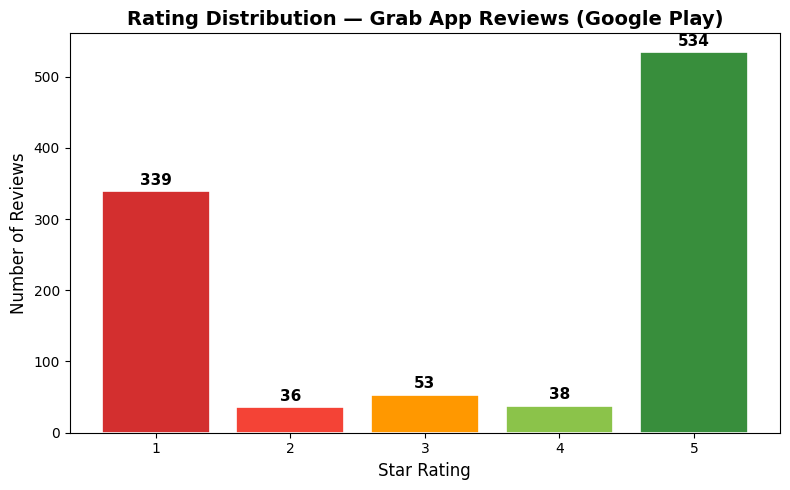

In [60]:
# Visualise rating distribution
plt.figure(figsize=(8, 5))
colors = ['#d32f2f', '#f44336', '#ff9800', '#8bc34a', '#388e3c']
rating_counts = df['rating'].value_counts().sort_index()
bars = plt.bar(rating_counts.index, rating_counts.values, color=colors, edgecolor='white', linewidth=1.2)

# Add value labels on bars
for bar, val in zip(bars, rating_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.title('Rating Distribution — Grab App Reviews (Google Play)', fontsize=14, fontweight='bold')
plt.xlabel('Star Rating', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.xticks([1, 2, 3, 4, 5])
plt.tight_layout() # Adjust layout to prevent title cutoff
plt.show()

---
## Sentiment Labelling

I assign sentiment labels based on star ratings:
- **Positive**: 4–5 stars
- **Neutral**: 3 stars
- **Negative**: 1–2 stars

In [61]:
# Map star ratings to sentiment labels
def assign_sentiment(rating):
    if rating >= 4:
        return 'Positive'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Negative'

df['sentiment'] = df['rating'].apply(assign_sentiment)

# Check distribution
print('Sentiment Label Distribution:')
print(df['sentiment'].value_counts())
print()
print(f'Positive: {(df["sentiment"]=="Positive").sum()} reviews ({(df["sentiment"]=="Positive").mean()*100:.1f}%)')
print(f'Neutral : {(df["sentiment"]=="Neutral").sum()} reviews ({(df["sentiment"]=="Neutral").mean()*100:.1f}%)')
print(f'Negative: {(df["sentiment"]=="Negative").sum()} reviews ({(df["sentiment"]=="Negative").mean()*100:.1f}%)')

Sentiment Label Distribution:
sentiment
Positive    572
Negative    375
Neutral      53
Name: count, dtype: int64

Positive: 572 reviews (57.2%)
Neutral : 53 reviews (5.3%)
Negative: 375 reviews (37.5%)


---
## Text Preprocessing

We apply the following preprocessing steps:
1. **Lowercasing** — Normalise all text to lowercase
2. **Remove URLs & Mentions** — Remove noise like links and @usernames
3. **Remove Punctuation & Special Characters** — Strip non-alphabetic characters
4. **Tokenization** — Split text into individual tokens (words)
5. **Stop Word Removal** — Remove common words that carry no meaning (e.g., 'the', 'is')
6. **Lemmatization** — Reduce words to their base/root form (e.g., 'running' → 'run')

In [62]:
# Initialise tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Add domain-specific stop words (app reviews tend to have these)
custom_stops = {'app', 'grab', 'use', 'get', 'go', 'one', 'also', 'would', 'could', 'please'}
stop_words.update(custom_stops)

print(f'Total stop words in use: {len(stop_words)}')

Total stop words in use: 208


In [63]:
# --- Step-by-step preprocessing pipeline ---

def preprocess_text(text):
    """
    Full text preprocessing pipeline:
    1. Lowercase
    2. Remove URLs
    3. Remove mentions and hashtags
    4. Remove punctuation and special characters
    5. Tokenize
    6. Remove stop words
    7. Lemmatize
    """
    # Step 1: Lowercase
    text = text.lower()

    # Step 2: Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # Step 3: Remove mentions (@user) and hashtags (#tag)
    text = re.sub(r'@\w+|#\w+', '', text)

    # Step 4: Remove punctuation and special characters (keep only letters and spaces)
    text = re.sub(r'[^a-z\s]', '', text)

    # Step 5: Tokenize
    tokens = word_tokenize(text)

    # Step 6: Remove stop words and short tokens
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]

    # Step 7: Lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return tokens


# Apply preprocessing
print('Applying preprocessing pipeline to all reviews...')
df['tokens'] = df['review'].astype(str).apply(preprocess_text)
df['clean_review'] = df['tokens'].apply(lambda tokens: ' '.join(tokens))

print('Preprocessing complete!')
print()
print('Example — Before & After:')
for i in range(3):
    print(f'[{i+1}] ORIGINAL : {df["review"].iloc[i]}')
    print(f'    CLEANED  : {df["clean_review"].iloc[i]}')
    print()

Applying preprocessing pipeline to all reviews...
Preprocessing complete!

Example — Before & After:
[1] ORIGINAL : pota wala makuha
    CLEANED  : pota wala makuha

[2] ORIGINAL : good 👍
    CLEANED  : good

[3] ORIGINAL : rider purposely cancel your booking when they knew price has increased. even though your booking is confirm and you have waited more than 10 minutes. part of legal scam. i wish i can blacklist or give 1 star to this type of rider
    CLEANED  : rider purposely cancel booking knew price increased even though booking confirm waited minute part legal scam wish blacklist give star type rider



In [64]:
# Show full preprocessed dataframe
df[['username', 'rating', 'sentiment', 'review', 'clean_review']].head(10)

,username,rating,sentiment,review,clean_review
0,舞風（Maikaze）,1,Negative,pota wala makuha,pota wala makuha
1,Sozhan Vithya,5,Positive,good 👍,good
2,Radio Kamek,1,Negative,rider purposely cancel your booking when they ...,rider purposely cancel booking knew price incr...
3,Kidwell Serongwane,5,Positive,Brilliant...,brilliant
4,Yu Shi,1,Negative,selalu bintang 1,selalu bintang
5,Justine Sandoval,5,Positive,Best Driver ever,best driver ever
6,Jericho Majait,5,Positive,nice,nice
7,Ani Romdayani,5,Positive,Thank you for helping all people can drop or p...,thank helping people drop pickup efficiency co...
8,Влад Обухов,1,Negative,Wonderful app. Your order can take 3 or 4 hour...,wonderful order take hour even sleep cancel or...
9,Vladislav Obukhov,1,Negative,I used the Grab app in Phuket. The inability t...,used phuket inability cancel order hasnt even ...


---
## Exploratory Analysis After Preprocessing

In [65]:
# Average token count before and after preprocessing
df['original_word_count'] = df['review'].astype(str).apply(lambda x: len(x.split()))
df['clean_word_count'] = df['tokens'].apply(len)

print(f'Avg word count BEFORE preprocessing : {df["original_word_count"].mean():.1f}')
print(f'Avg word count AFTER preprocessing  : {df["clean_word_count"].mean():.1f}')
print(f'Noise reduction                     : {(1 - df["clean_word_count"].mean()/df["original_word_count"].mean())*100:.1f}%')

Avg word count BEFORE preprocessing : 17.0
Avg word count AFTER preprocessing  : 9.8
Noise reduction                     : 42.5%


---
## Save Processed Dataset

In [66]:
# Save preprocessed data to CSV
output_path = 'grab_reviews_preprocessed.csv'
df[['username', 'rating', 'sentiment', 'date', 'review', 'clean_review']].to_csv(output_path, index=False)

print(f'Dataset saved to: {output_path}')
print(f'Total rows: {len(df)}')
print(f'Columns saved: username, rating, sentiment, date, review, clean_review')

Dataset saved to: grab_reviews_preprocessed.csv
Total rows: 1000
Columns saved: username, rating, sentiment, date, review, clean_review
